In [1]:
import pandas as pd
import numpy as np

# Carga de Datos

In [2]:
df = pd.read_csv('../Data/datos_historicos.csv')
df.sort_values('Fecha', inplace=True) 

model_cols = df.columns

# Eliminamos filas con datos faltantes (basicamente el primer partido de cada seleccion tiene las variables a Null al hacer las medias moviles)
df.dropna(inplace=True) 

df.head()

,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,h2h_draw_rate,h2h_goles_avg_Local,Peso_Local,avg_Goles_esperados_(xG)_total_Local,avg_h2h_win_rate_total_Local,...,diff_avg__sentinel_3,diff_avg__sentinel_5,diff_trend_xG_5,diff_clean_sheet_rate_5,diff_Puntos,Prob_Implicita_ELO,diff_Tier,diff_Valor_Mercado,diff_h2h_win_rate,diff_h2h_goles
19,2021-03-27,Noruega,Turquía,0,3.0,0.333333,1.6,1.00,4.5740,0.333333,...,0.0,0.0,0.0,0.500000,-37.0,0.446953,0,4.470,0.0,0.0
21,2021-03-27,República Checa,Bélgica,1,1.0,0.333333,1.6,1.00,3.0770,0.333333,...,0.0,0.0,0.0,0.000000,-324.0,0.134110,3,-13.820,0.0,0.0
30,2021-03-28,Georgia,España,1,2.0,0.333333,1.6,0.92,0.9620,0.333333,...,0.0,0.0,0.0,-0.500000,-378.0,0.101932,2,-37.380,0.0,0.0
39,2021-03-30,Gibraltar,Países Bajos,0,7.0,0.333333,1.6,0.70,0.2410,0.333333,...,0.0,0.0,0.0,-0.333333,-721.0,0.015513,2,-28.937,0.0,0.0
36,2021-03-30,Turquía,Letonia,3,3.0,0.333333,1.6,1.00,1.5355,0.333333,...,0.0,0.0,0.0,0.000000,405.0,0.911442,0,17.891,0.0,0.0


Transformamos el resultado (formato 1X2) a numérico para que el modelo lo pueda "entender".

In [3]:
# 1. Definimos el diccionario de traducción
mapeo_resultados = {
    '1': 0,  # Victoria Local
    'X': 1,  # Empate
    '2': 2   # Victoria Visitante
}

# 2. Aplicamos la traducción creando una nueva columna numérica
df['Resultado_1X2_Num'] = df['Resultado_1X2'].map(mapeo_resultados)

# 3. Ahora definimos 'y' apuntando a esta nueva columna
y = df['Resultado_1X2_Num']

Creamos el dataframe que utilizaremos para predecir los resultados (matriz X de covariables).

In [4]:
X = df.drop(columns=['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Resultado_1X2_Num', 'Goles_Local', 'Goles_Visitante'])
X.columns

Index(['h2h_draw_rate', 'h2h_goles_avg_Local', 'Peso_Local',
       'avg_Goles_esperados_(xG)_total_Local', 'avg_h2h_win_rate_total_Local',
       'avg_h2h_goles_avg_total_Local', 'avg__sentinel_total_Local',
       'avg_Remates_a_puerta_2_Local', 'avg_Córneres_2_Local',
       'avg_Tarjetas_amarillas_2_Local', 'avg_Faltas_2_Local',
       'avg_Paradas_2_Local', 'avg_Pases_Pct_2_Local',
       'avg_Pases_Exitosos_2_Local', 'avg_Goles_2_Local', 'avg_Ptos_2_Local',
       'avg_xGA_2_Local', 'avg_Paradas_Share_2_Local',
       'avg_h2h_win_rate_2_Local', 'avg_h2h_goles_avg_2_Local',
       'avg__sentinel_2_Local', 'avg__sentinel_3_Local',
       'avg__sentinel_5_Local', 'clean_sheet_rate_5_Local', 'trend_xG_5_Local',
       'forma_vs_historia_Local', 'Peso_Visitante',
       'avg_Goles_esperados_(xG)_total_Visitante',
       'avg_Pases_Pct_total_Visitante', 'avg_h2h_win_rate_total_Visitante',
       'avg_h2h_goles_avg_total_Visitante', 'avg__sentinel_total_Visitante',
       'avg_Remates_

# Ajuste del Modelo

In [6]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from sklearn.calibration import CalibratedClassifierCV

# 1. Split Temporal (85% Train, 15% Test)
split_index = int(len(df) * 0.85)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_1X2, y_test_1X2 = y.iloc[:split_index], y.iloc[split_index:]
df_train, df_test = df.iloc[:split_index].copy(), df.iloc[split_index:].copy()  # Copias para evitar SettingWithCopyWarning

# Variables de interes de goles
y_train_goles_L = df['Goles_Local'].iloc[:split_index]
y_train_goles_V = df['Goles_Visitante'].iloc[:split_index]
y_test_goles_L = df['Goles_Local'].iloc[split_index:]
y_test_goles_V = df['Goles_Visitante'].iloc[split_index:]

# 2. Configuración de Validación Cruzada Temporal
# Esto evita mezclar el futuro con el pasado durante la búsqueda de hiperparámetros
tscv = TimeSeriesSplit(n_splits=5) 

In [7]:
# 3. Espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
    'max_depth': [2, 3, 5, 8],
    'subsample': [0.8, 0.9, 1.0],
    'reg_lambda': [0.1, 0.5, 1.0, 5.0],
    'gamma': [0, 0.1],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print("Fase 1: Entrenando predictores de Goles (Poisson)...")

# --- Creación de pesos (Partidos con >= 3 goles pesan el triple para que el modelo no sea demasiado conservador) ---
pesos_train_L = np.where(y_train_goles_L >= 3, 1.5, 1.0)
pesos_train_V = np.where(y_train_goles_V >= 3, 1.5, 1.0)

# 4. Modelos Base: Regresores de Goles (Usamos objetivo Tweedie)
xgb_reg_L = xgb.XGBRegressor(
    objective='reg:tweedie', 
    tweedie_variance_power=1.5, # 1.0 es Poisson puro, 2.0 es Gamma. 1.5 es ideal para fútbol.
    random_state=42
)
xgb_reg_V = xgb.XGBRegressor(
    objective='reg:tweedie', 
    tweedie_variance_power=1.5, 
    random_state=42
)

# Búsqueda de mejores parámetros para los goles
# NOTA: n_iter represnta cuantos de los hiperparametros testearemos para estimar el modelo. A mayor numero tarda mas pero probamos mas modelos para buscar el mejor. 
search_L = RandomizedSearchCV(xgb_reg_L, param_grid, cv=tscv, n_iter=1000, scoring='neg_mean_poisson_deviance', random_state=42, n_jobs=-1)
search_V = RandomizedSearchCV(xgb_reg_V, param_grid, cv=tscv, n_iter=1000, scoring='neg_mean_poisson_deviance', random_state=42, n_jobs=-1)

# --- Inyectamos los pesos en el entrenamiento ---
search_L.fit(X_train, y_train_goles_L, sample_weight=pesos_train_L)
search_V.fit(X_train, y_train_goles_V, sample_weight=pesos_train_V)

mejor_modelo_L = search_L.best_estimator_
mejor_modelo_V = search_V.best_estimator_

# 5. Generar Meta-Variables (Predicciones de Goles)
kf_meta = KFold(n_splits=5, shuffle=False)

print("Generando proyecciones de goles para el set de entrenamiento...")
# --- Pasamos los pesos a cross_val_predict mediante params ---
pred_goles_L_train = cross_val_predict(mejor_modelo_L, X_train, y_train_goles_L, cv=kf_meta, params={'sample_weight': pesos_train_L}) ** 1.5 * X_train['Peso_Local']
pred_goles_V_train = cross_val_predict(mejor_modelo_V, X_train, y_train_goles_V, cv=kf_meta, params={'sample_weight': pesos_train_V}) ** 1.5 * X_train['Peso_Visitante']

# En el test, simplemente predecimos de forma normal usando el modelo ya entrenado
print("Generando proyecciones de goles para el set de prueba...")

# Ajustamos los goles que predice el modelo ya que es demasiado conservador (elevamos a 1.5 y ajustamos segun el continente del equipo)
pred_goles_L_test = mejor_modelo_L.predict(X_test) ** 1.5 * X_test['Peso_Local']
pred_goles_V_test = mejor_modelo_V.predict(X_test) ** 1.5 * X_test['Peso_Visitante']

# Añadimos las predicciones matemáticas como nuevas columnas a los datos
X_train_meta = X_train.copy()
X_test_meta = X_test.copy()

X_train_meta['Pred_Goles_L'] = pred_goles_L_train
X_train_meta['Pred_Goles_V'] = pred_goles_V_train
X_test_meta['Pred_Goles_L'] = pred_goles_L_test
X_test_meta['Pred_Goles_V'] = pred_goles_V_test

print("Fase 2: Entrenando el Clasificador Final (1X2)...")

# 6. Modelo Final: Clasificador 1X2 
xgb_clf = xgb.XGBClassifier(objective='multi:softprob', num_class=3, base_score=0.5, random_state=42)

# NOTA: n_iter representa cuantos de los hiperparametros testearemos para estimar el modelo. A mayor numero tarda mas pero probamos mas modelos para buscar el mejor. 
search_clf = RandomizedSearchCV(xgb_clf, param_grid, cv=tscv, n_iter=5000, scoring='accuracy', random_state=42, n_jobs=-1)
search_clf.fit(X_train_meta, y_train_1X2)

mejor_clf = search_clf.best_estimator_

# --- CALIBRACION --- #
print("Fase 3: Calibrando las probabilidades...")

# 1. Recuperamos la estructura matemática del mejor modelo ya encontrado
mejor_modelo_sin_entrenar = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=3, 
    base_score=0.5,
    random_state=42,
    **search_clf.best_params_ # Le inyectamos los hiperparámetros ganadores
)

# 2. Envolvemos el modelo en el calibrador
clasificador_calibrado = CalibratedClassifierCV(
    estimator=mejor_modelo_sin_entrenar, 
    method='isotonic', 
    cv=tscv
)

# 3. Entrenamos el calibrador sobre los datos
clasificador_calibrado.fit(X_train_meta, y_train_1X2)
print("¡Calibración completada!")

# 4. Generamos las predicciones REALES y calibradas
predicciones_finales = clasificador_calibrado.predict(X_test_meta)
probabilidades_finales = clasificador_calibrado.predict_proba(X_test_meta)

print("\n--- RESULTADOS DEL MODELO HÍBRIDO ---")
print(f"Mejores parámetros 1X2: {search_clf.best_params_}")
print(classification_report(y_test_1X2, predicciones_finales))

# Mejores parámetros 1X2: {'subsample': 0.9, 'reg_lambda': 0.1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 0, 'colsample_bytree': 0.8}

Fase 1: Entrenando predictores de Goles (Poisson)...
Generando proyecciones de goles para el set de entrenamiento...
Generando proyecciones de goles para el set de prueba...
Fase 2: Entrenando el Clasificador Final (1X2)...
Fase 3: Calibrando las probabilidades...
¡Calibración completada!

--- RESULTADOS DEL MODELO HÍBRIDO ---
Mejores parámetros 1X2: {'subsample': 0.9, 'reg_lambda': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
              precision    recall  f1-score   support

           0       0.65      0.91      0.76       100
           1       0.36      0.07      0.11        59
           2       0.57      0.65      0.61        55

    accuracy                           0.61       214
   macro avg       0.53      0.54      0.49       214
weighted avg       0.55      0.61      0.54       214



## Comprobación Modelo

/Users/anynou/Documents/mis_repos/Simulaciones_Mundial/simulacion_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Calculando valores SHAP para Goles (Enfoque de escudo Wrapper)...


100%|██████████| 100/100 [00:07<00:00, 12.95it/s]


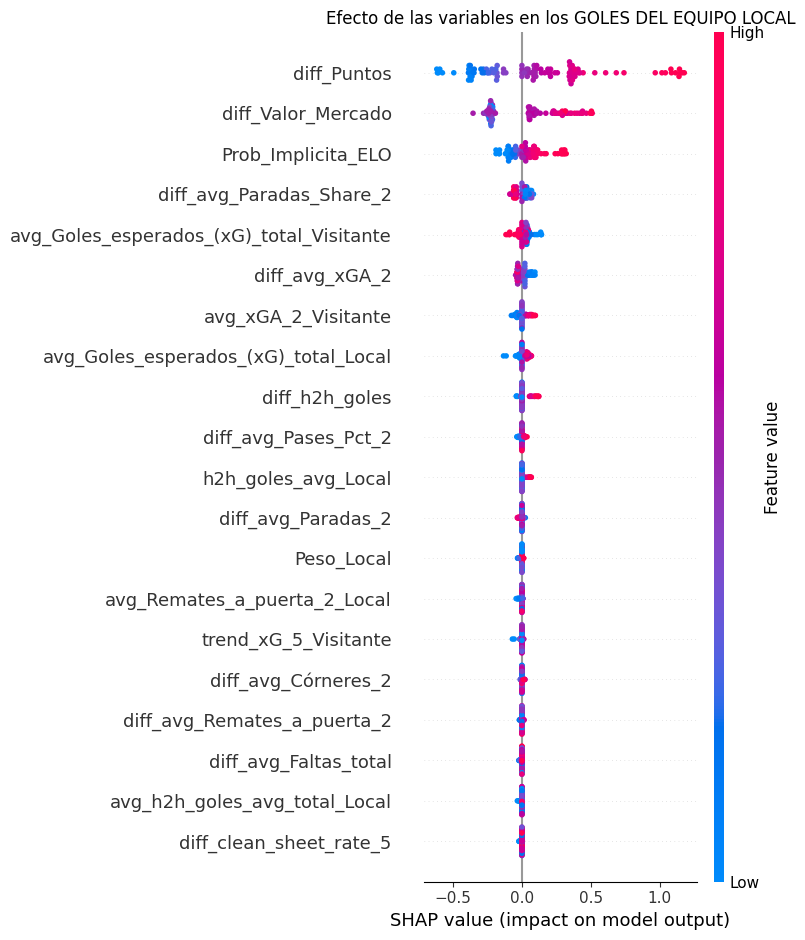

100%|██████████| 100/100 [00:07<00:00, 12.87it/s]


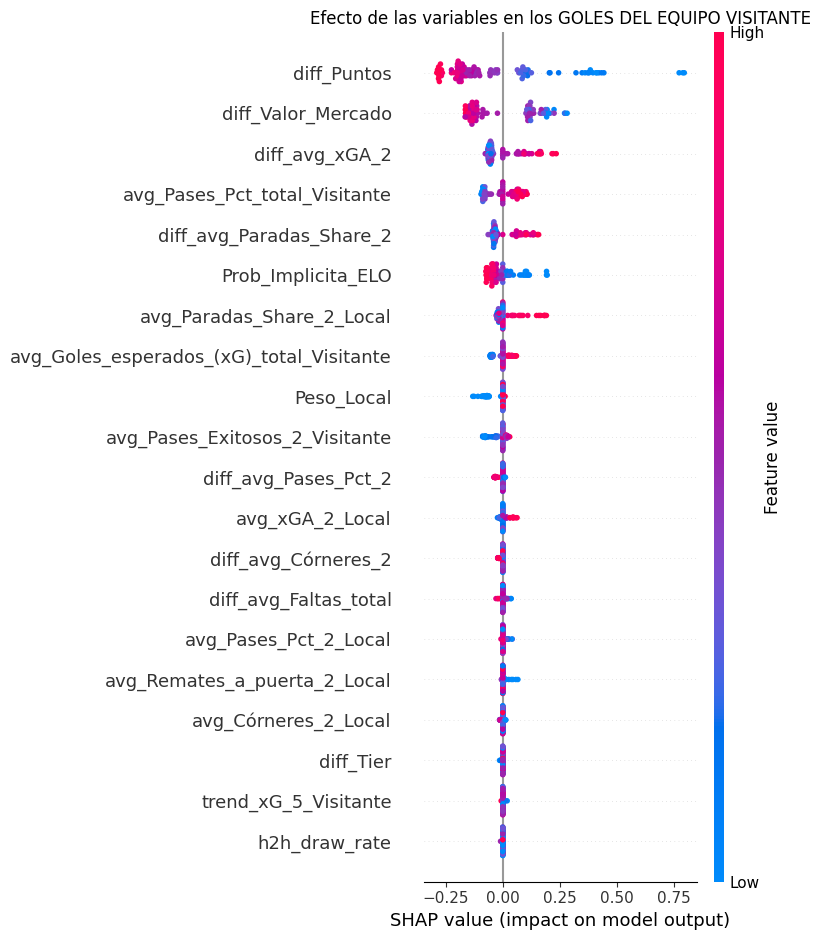

In [9]:
import matplotlib.pyplot as plt
import shap
import warnings

# 3. EL EFECTO Y LA DIRECCIÓN (SHAP con Enfoque de Wrapper)
print("\nCalculando valores SHAP para Goles (Enfoque de escudo Wrapper)...")

background_goles = shap.sample(X_train, 50)
X_test_shap = X_test.head(100)
columnas_goles = X_train.columns

# Envolvemos la predicción para que SHAP no vea el modelo original de XGBoost
# y de paso nos aseguramos de que el formato siga siendo un DataFrame válido
def predict_goles_L(X_array):
    X_df = pd.DataFrame(X_array, columns=columnas_goles)
    return mejor_modelo_L.predict(X_df)

def predict_goles_V(X_array):
    X_df = pd.DataFrame(X_array, columns=columnas_goles)
    return mejor_modelo_V.predict(X_df)

# --- EXPLICADOR PARA GOLES LOCALES ---
explainer_L = shap.KernelExplainer(predict_goles_L, background_goles)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values_L = explainer_L.shap_values(X_test_shap)

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en los GOLES DEL EQUIPO LOCAL")
shap.summary_plot(shap_values_L, X_test_shap, show=False)
plt.tight_layout()
plt.show()

# --- EXPLICADOR PARA GOLES VISITANTES ---
explainer_V = shap.KernelExplainer(predict_goles_V, background_goles)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values_V = explainer_V.shap_values(X_test_shap)

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en los GOLES DEL EQUIPO VISITANTE")
shap.summary_plot(shap_values_V, X_test_shap, show=False)
plt.tight_layout()
plt.show()


--- DIAGNÓSTICO DEL MODELO 1X2 ---

Top 15 Variables más determinantes:
                          Variable  Importancia
                      Pred_Goles_V     0.067200
                diff_Valor_Mercado     0.066185
                       diff_Puntos     0.060275
                      Pred_Goles_L     0.044442
                Prob_Implicita_ELO     0.026933
                   diff_avg_Ptos_2     0.018066
      clean_sheet_rate_5_Visitante     0.017159
          diff_avg_Paradas_Share_2     0.017045
                    diff_avg_xGA_2     0.016612
                    Peso_Visitante     0.016175
                   avg_xGA_2_Local     0.015745
                        Peso_Local     0.015331
         diff_avg_Pases_Exitosos_2     0.015315
                  avg_Ptos_2_Local     0.014673
avg_Tarjetas_amarillas_2_Visitante     0.014625

Calculando valores SHAP (Enfoque aislado para evitar conflictos de dimensiones)...


100%|██████████| 100/100 [00:07<00:00, 13.28it/s]


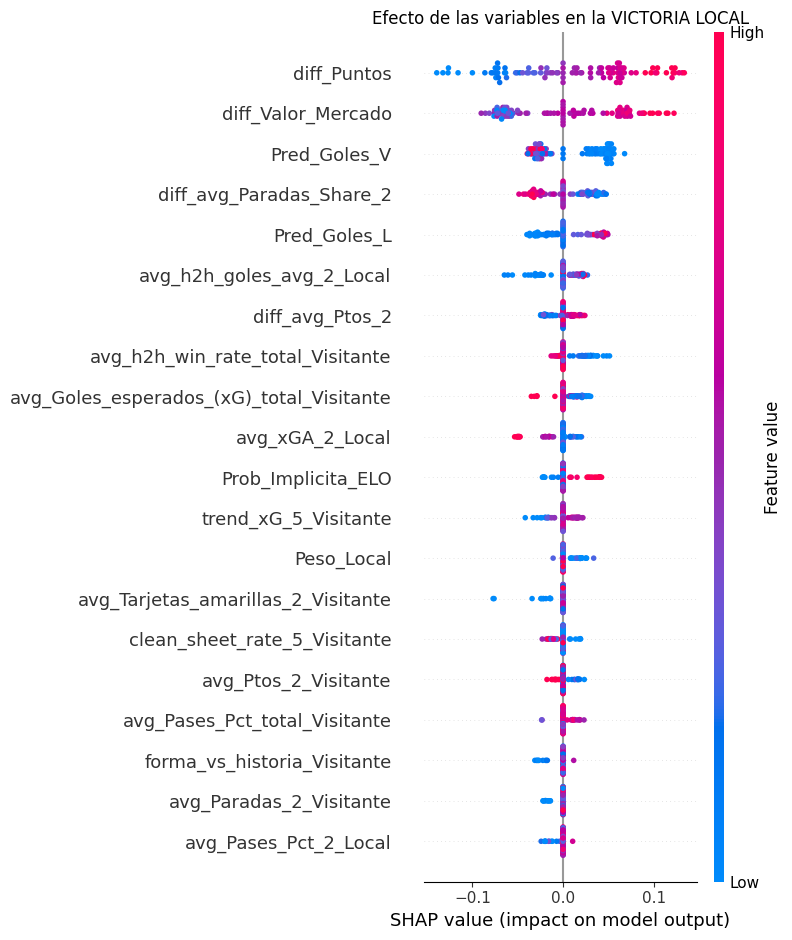

100%|██████████| 100/100 [00:07<00:00, 13.11it/s]


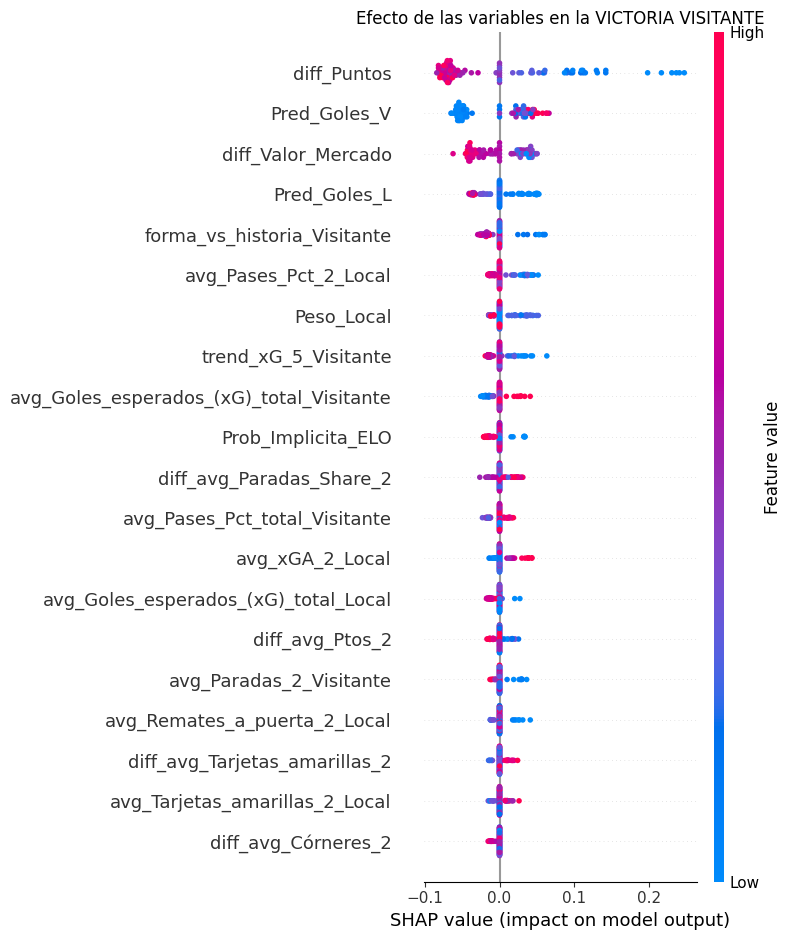

In [10]:
print("\n--- DIAGNÓSTICO DEL MODELO 1X2 ---")

# 1. IMPORTANCIA GLOBAL 
importancias = mejor_clf.feature_importances_
columnas = X_train_meta.columns

df_importancia = pd.DataFrame({
    'Variable': columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("\nTop 15 Variables más determinantes:")
print(df_importancia.head(15).to_string(index=False))

# 2. EL EFECTO Y LA DIRECCIÓN (SHAP con Enfoque de Clase Aislada)
print("\nCalculando valores SHAP (Enfoque aislado para evitar conflictos de dimensiones)...")

background = shap.sample(X_train_meta, 50)
X_test_sample = X_test_meta.head(100) 

# --- EXPLICADOR PARA VICTORIA LOCAL ---
def prob_local(X_array):
    X_df = pd.DataFrame(X_array, columns=columnas)
    return mejor_clf.predict_proba(X_df)[:, 0] 

explainer_local = shap.KernelExplainer(prob_local, background)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Al pedir solo 1 clase, shap_values_local ya es una matriz plana y perfecta
    shap_values_local = explainer_local.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en la VICTORIA LOCAL")
shap.summary_plot(shap_values_local, X_test_sample, show=False)
plt.tight_layout()
plt.show()

# --- EXPLICADOR PARA VICTORIA VISITANTE ---
def prob_visitante(X_array):
    X_df = pd.DataFrame(X_array, columns=columnas)
    return mejor_clf.predict_proba(X_df)[:, 2]

explainer_visitante = shap.KernelExplainer(prob_visitante, background)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    shap_values_visitante = explainer_visitante.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
plt.title("Efecto de las variables en la VICTORIA VISITANTE")
shap.summary_plot(shap_values_visitante, X_test_sample, show=False)
plt.tight_layout()
plt.show()

Comprobamos las predicciones en la muestra de Test.

In [11]:
df_test['Resultado_1X2_Pred'] = predicciones_finales
df_test['Prob_1'] = probabilidades_finales[:, 0]
df_test['Prob_X'] = probabilidades_finales[:, 1]
df_test['Prob_2'] = probabilidades_finales[:, 2]
df_test['Pred_Goles_L'] = pred_goles_L_test
df_test['Pred_Goles_V'] = pred_goles_V_test

df_test[['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Goles_Local', 'Goles_Visitante', 'Pred_Goles_L', 'Pred_Goles_V', 'Resultado_1X2_Pred', 'Prob_1', 'Prob_X', 'Prob_2']].tail(10)

,Fecha,Equipo_Local,Equipo_Visitante,Resultado_1X2,Goles_Local,Goles_Visitante,Pred_Goles_L,Pred_Goles_V,Resultado_1X2_Pred,Prob_1,Prob_X,Prob_2
1572,2026-06-08,Países Bajos,Uzbekistán,1,2,1.0,3.633056,0.399215,0,0.821975,0.133373,0.044652
1574,2026-06-08,Colombia,Jordania,1,2,0.0,3.521769,0.282737,0,0.808969,0.153560,0.037472
1575,2026-06-09,Perú,España,2,1,3.0,0.404792,2.833174,2,0.182030,0.291617,0.526353
1577,2026-06-09,RD Congo,Chile,2,1,2.0,1.408804,0.441407,0,0.625257,0.314083,0.060660
1581,2026-06-10,Irak,Venezuela,2,0,2.0,1.128804,0.720024,1,0.354135,0.365323,0.280543
1580,2026-06-10,Portugal,Nigeria,1,2,1.0,3.328427,0.584150,0,0.757590,0.143619,0.098791
1582,2026-06-10,Inglaterra,Costa Rica,1,3,0.0,4.705714,0.227500,0,0.765291,0.192429,0.042280
1578,2026-06-10,Argentina,Islandia,1,3,0.0,6.529193,0.173059,0,0.865909,0.121539,0.012552
1579,2026-06-10,Bolivia,Argelia,2,0,4.0,0.649993,1.008309,2,0.257907,0.192861,0.549232
1583,2026-06-10,Arabia Saudí,Senegal,X,0,0.0,0.515792,1.459248,2,0.213894,0.289305,0.496802


In [12]:
pd.crosstab(df_test['Resultado_1X2_Pred'], df_test['Resultado_1X2'])

Resultado_1X2,1,2,X
Resultado_1X2_Pred,,,
0,91,13,36
1,1,6,4
2,8,36,19


# Pipeline de prediccón

Una vez tenemos nuestro modelo (hiperparámertos y variables) re-entrenamos el mejor modelo que hemos obtenido con toda la muestra que tenemos previa al Mundial apra tener el modelo más completo posible. 

Guardamos los modelos (Goles y 1X2) para pdoer utiliaarlos a continuación.

In [13]:
print("\n=======================================================")
print(" FASE DE PRODUCCIÓN: REENTRENANDO CON EL 100% DE DATOS")
print("=======================================================")

import joblib

# 'X' y 'y' (y_1X2) son tus datasets completos originales antes del split
y_goles_L_full = df['Goles_Local']
y_goles_V_full = df['Goles_Visitante']

# --- Novedad: Creación de pesos para el 100% de los datos ---
pesos_full_L = np.where(y_goles_L_full >= 3, 1.5, 1.0)
pesos_full_V = np.where(y_goles_V_full >= 3, 1.5, 1.0)

# --- 1. GENERAR META-VARIABLES SIN TRAMPAS (OOF en todo X) ---
# Usamos cross_val_predict para que el clasificador final aprenda 
# usando proyecciones realistas con su margen de error.
print("1/4 Generando Goles Esperados para todo el histórico...")
kf_meta_full = KFold(n_splits=5, shuffle=False)

# Inyectamos los pesos con 'params'
pred_goles_L_full = cross_val_predict(mejor_modelo_L, X, y_goles_L_full, cv=kf_meta_full, params={'sample_weight': pesos_full_L})
pred_goles_V_full = cross_val_predict(mejor_modelo_V, X, y_goles_V_full, cv=kf_meta_full, params={'sample_weight': pesos_full_V})

X_meta_full = X.copy()
X_meta_full['Pred_Goles_L'] = pred_goles_L_full
X_meta_full['Pred_Goles_V'] = pred_goles_V_full
X_meta_full['Pred_Goles_L'] = X_meta_full['Pred_Goles_L'] 
X_meta_full['Pred_Goles_V'] = X_meta_full['Pred_Goles_V'] 


# Si añadiste el Ratio de Dominio, lo calculas aquí también:
# X_meta_full['Ratio_Dominio'] = X_meta_full['Pred_Goles_L'] / (X_meta_full['Pred_Goles_V'] + 0.1)

# --- 2. ENTRENAR LOS REGRESORES DE GOLES FINALES ---
# Ahora sí, los motores de goles memorizan y aprenden del 100% de los datos
print("2/4 Entrenando modelos de goles definitivos...")
mejor_modelo_L.fit(X, y_goles_L_full, sample_weight=pesos_full_L)
mejor_modelo_V.fit(X, y_goles_V_full, sample_weight=pesos_full_V)

# --- 3. CONFIGURAR EL CLASIFICADOR FINAL CON LOS MEJORES PARÁMETROS ---
print("3/4 Entrenando clasificador 1X2 definitivo...")
modelo_1X2_final = xgb.XGBClassifier(
    objective='multi:softprob', 
    num_class=3, 
    base_score=0.5, 
    random_state=42,
    **search_clf.best_params_ # Inyectamos la configuración ganadora
)

# --- 4. CALIBRACIÓN FINAL EN EL 100% DE LOS DATOS ---
print("4/4 Calibrando probabilidades finales...")
clasificador_calibrado_final = CalibratedClassifierCV(
    estimator=modelo_1X2_final, 
    method='isotonic', 
    cv=tscv # Seguimos usando TimeSeriesSplit para la calibración interna
)
clasificador_calibrado_final.fit(X_meta_full, y)

print("¡Modelo Listo para el Mundial!")

# =====================================================================
# GUARDADO DE ARCHIVOS PARA EL PIPELINE
# =====================================================================
joblib.dump(mejor_modelo_L, 'modelo_goles_L.pkl')
joblib.dump(mejor_modelo_V, 'modelo_goles_V.pkl')
joblib.dump(clasificador_calibrado_final, 'modelo_1X2_calibrado.pkl')
joblib.dump(list(X.columns), 'columnas_entrenamiento.pkl')

print("Motores actualizados sobrescritos en el disco duro con éxito.")


 FASE DE PRODUCCIÓN: REENTRENANDO CON EL 100% DE DATOS
1/4 Generando Goles Esperados para todo el histórico...
2/4 Entrenando modelos de goles definitivos...
3/4 Entrenando clasificador 1X2 definitivo...
4/4 Calibrando probabilidades finales...
¡Modelo Listo para el Mundial!
Motores actualizados sobrescritos en el disco duro con éxito.


In [14]:
# Guardamos los tres modelos entrenados
joblib.dump(mejor_modelo_L, 'modelo_goles_L.pkl')
joblib.dump(mejor_modelo_V, 'modelo_goles_V.pkl')
joblib.dump(mejor_clf, 'modelo_1X2.pkl')
joblib.dump(clasificador_calibrado, 'modelo_1X2_calibrado.pkl')

# Guardamos también la lista exacta de variables independientes
# XGBoost colapsará si el nuevo dataset tiene las columnas en otro orden o le falta alguna
joblib.dump(list(X_train.columns), 'columnas_entrenamiento.pkl')

['columnas_entrenamiento.pkl']

# Predicciones para el Mundial

In [15]:
# Variables y funciones auxiliares que utilizamos en la ingeniería de variables (para incluirla en los partidos el mundial).

def asignar_tier(puntos):
    if puntos >= 1700: return 1   # Élite (Francia, Argentina, España...)
    elif puntos >= 1600: return 2 # Nivel Alto (Suiza, Senegal, Japón...)
    elif puntos >= 1500: return 3 # Nivel Medio (Haití, Jordania...)
    else: return 4                # Nivel Bajo (Curazao, etc.)

mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',
    
    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    
    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    
    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',
    
    # ASIA (AFC) - Nota: Australia compite deportivamente en Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

pesos_continente = {
    'Europa': 1.00,       # No se descuenta nada
    'Sudamérica': .95,   # Se descuenta un 5%
    'Norteamérica': 0.75, # Se les quita un 25% de su poder ofensivo
    'Africa': 0.6,
    'Asia': 0.7,         # Se les quita un 30% 
    'Oceanía': 0.5       # Sus medias valen la mitad en un Mundial
}

Hemos incluido un parámetro `T` de temperatura que básicamente agudiza las probabilidades ya que los modelos tienden a ser muy conservadores al estimar la probabildiad. Lo que hace este parámetro cuando `T < 1` es que transforma una probabilidad "media" como `0.5` a `0.67` por ejemplo. Esto nos ayudrá a tener demasiado ruido y variabiliad al hacer las simulaciones de Monte Carlo. Puedes jugar con este parámetro para ver como afecta a las predicciones y a las simulaciones. 

También he "duplicado" los datasets para hacer predicciones en cada partido de dos formas. Por ejemplo España-Uruguay hacemos la predicción para el partido España-Uruguay y Uruguay-España para eliminar el efecto de Local/Visitante en los datos de entrenamiento. Esto puede eliminarse indicando `sede_neutral = False`.

In [16]:
# ====================================================================
# 2. PIPELINE DE PREDICCIÓN DEFINITIVO
# ====================================================================

def pipeline_prediccion(df_bruto, sede_neutral=True, T=0.5):
    # Carga de modelos
    modelo_L = joblib.load('modelo_goles_L.pkl')
    modelo_V = joblib.load('modelo_goles_V.pkl')
    modelo_1X2 = joblib.load('modelo_1X2_calibrado.pkl')
    columnas_base = joblib.load('columnas_entrenamiento.pkl')
    
    def obtener_predicciones_crudas(df_temp):
        df_calc = df_temp.copy()
        
        # Diferencias
        columnas_promedios_local = [col for col in df_calc.columns if col.endswith(('_5_Local', '_2_Local', '_total_Local')) and col.startswith('avg_')]
        for col_local in columnas_promedios_local:
            col_visitante = col_local.replace('_Local', '_Visitante')
            if col_visitante in df_calc.columns:
                nombre_base = col_local.replace('_Local', '')
                df_calc[f"diff_{nombre_base}"] = df_calc[col_local] - df_calc[col_visitante]

        if 'Puntos_Local' in df_calc.columns and 'Puntos_Visitante' in df_calc.columns:
            df_calc['diff_Puntos'] = df_calc['Puntos_Local'] - df_calc['Puntos_Visitante']
            df_calc['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df_calc['diff_Puntos'] / 400))
            df_calc['diff_Tier'] = df_calc['Puntos_Local'].apply(asignar_tier) - df_calc['Puntos_Visitante'].apply(asignar_tier)

        # Continentes y Pesos
        df_calc['Continente_Local'] = df_calc['Equipo_Local'].map(mapa_continentes)
        df_calc['Continente_Visitante'] = df_calc['Equipo_Visitante'].map(mapa_continentes)
        df_calc['Peso_Local'] = df_calc['Continente_Local'].map(pesos_continente)
        df_calc['Peso_Visitante'] = df_calc['Continente_Visitante'].map(pesos_continente)
        
        # EL FIX IMPORTANTE AQUÍ:
        df_calc.drop(['Continente_Local', 'Continente_Visitante'], axis=1, inplace=True) 

        # Rellenar y alinear
        for col in columnas_base:
            if col not in df_calc.columns:
                df_calc[col] = 0
        X_listo = df_calc[columnas_base]
        
        # Predicciones
        goles_L = modelo_L.predict(X_listo) # ** 1.5 * X_listo['Peso_Local']
        goles_V = modelo_V.predict(X_listo) # ** 1.5 * X_listo['Peso_Visitante']
        
        X_meta = X_listo.copy()
        X_meta['Pred_Goles_L'] = goles_L 
        X_meta['Pred_Goles_V'] = goles_V 
        probs = modelo_1X2.predict_proba(X_meta)
        
        return goles_L, goles_V, probs

    # --- PREDICCIÓN NORMAL Y ESPEJO ---
    df_normal = df_bruto.copy()
    
    # Dejamos pasar el Grupo si existe
    cols_contexto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante']
    if 'Grupo' in df_normal.columns:
        cols_contexto.append('Grupo')
        
    contexto = df_normal[cols_contexto].copy()
    
    goles_L_norm, goles_V_norm, probs_norm = obtener_predicciones_crudas(df_normal)
    
    if not sede_neutral:
        resultados = contexto.copy()
        resultados['xG_Modelo_Local'] = goles_L_norm.round(2)
        resultados['xG_Modelo_Visitante'] = goles_V_norm.round(2)
        resultados['Prob_VLocal'] = probs_norm[:, 0]
        resultados['Prob_Empate'] = probs_norm[:, 1]
        resultados['Prob_Visitante'] = probs_norm[:, 2]
        return resultados
        
    df_inverso = df_bruto.copy()
    nuevas_columnas = []
    for col in df_inverso.columns:
        if col.endswith('_Local'): nuevas_columnas.append(col.replace('_Local', '_Visitante'))
        elif col.endswith('_Visitante'): nuevas_columnas.append(col.replace('_Visitante', '_Local'))
        else: nuevas_columnas.append(col)
            
    df_inverso.columns = nuevas_columnas
    goles_L_inv, goles_V_inv, probs_inv = obtener_predicciones_crudas(df_inverso)
    
    # --- SÍNTESIS ---
    resultados = contexto.copy()
    resultados['xG_Modelo_Local'] = ((goles_L_norm + goles_V_inv) / 2).round(2)
    resultados['xG_Modelo_Visitante'] = ((goles_V_norm + goles_L_inv) / 2).round(2)
    
    resultados['Prob_Local'] = (probs_norm[:, 0] + probs_inv[:, 2]) / 2
    resultados['Prob_Empate'] = (probs_norm[:, 1] + probs_inv[:, 1]) / 2
    resultados['Prob_Visitante'] = (probs_norm[:, 2] + probs_inv[:, 0]) / 2

    # Afilado por temperatura
    probs_afiladas = resultados[['Prob_Local', 'Prob_Empate', 'Prob_Visitante']] ** (1 / T)
    s = probs_afiladas.sum(axis=1).replace(0, 1e-12)
    resultados[['Prob_Local', 'Prob_Empate', 'Prob_Visitante']] = probs_afiladas.div(s, axis=0)
    
    return resultados

In [17]:
# Ejemplo de ejecucion (puedes jugar con T para ver como funcinoa)
df_predicciones = pipeline_prediccion(df, T = 0.3)
df_predicciones.tail()

,Fecha,Equipo_Local,Equipo_Visitante,xG_Modelo_Local,xG_Modelo_Visitante,Prob_Local,Prob_Empate,Prob_Visitante
1580,2026-06-10,Portugal,Nigeria,1.48,1.34,0.746765,0.054245,0.198991
1582,2026-06-10,Inglaterra,Costa Rica,1.86,1.28,0.922752,0.053382,0.023867
1578,2026-06-10,Argentina,Islandia,2.00,1.48,0.931661,0.043098,0.025241
1579,2026-06-10,Bolivia,Argelia,1.15,1.33,0.481908,0.092921,0.425170
1583,2026-06-10,Arabia Saudí,Senegal,0.93,1.35,0.333594,0.174348,0.492058


# Simulaciones de Monte Carlo

Cargamos los datos con las covariables para los partidos del Mundial y los partidos de las fases de grupos. 

In [18]:
# ====================================================================
# 1. CARGA Y PREPARACIÓN DEL MUNDIAL 2026 
# ====================================================================

# Datos con todos los partidos de la fase de grupos
df_mundial = pd.read_csv('../Data/partidos_mundial.csv')[['Fecha', 'Equipo_Local', 'Equipo_Visitante']]
# Dataset con las covariables de cada seleccion
df_vars = pd.read_csv('../Data/datos_mundial.csv').sort_values('Fecha')
# Datos con el grupo en el que esta cada seleccion
grupos = pd.read_csv('../Data/grupos_mundial.csv', sep=";")

# Cruzamos los datos del Local y Visitante
aux = df_mundial.merge(df_vars, left_on=['Equipo_Local'], right_on=['Equipo'], how='left')
df_mundial_vars = aux.merge(df_vars, left_on=['Equipo_Visitante'], right_on=['Equipo'], how='left')

# Limpieza de nombres cruzados
df_mundial_vars.drop(columns=['Equipo_x', 'Equipo_y', 'Fecha_x', 'Fecha_y', 'Resultado_1X2_x', 'Resultado_1X2_y', 'Tipo_Equipo_x', 'Tipo_Equipo_y'], inplace=True)
df_mundial_vars.columns = df_mundial_vars.columns.str.replace(r'_x$', '_Local', regex=True)
df_mundial_vars.columns = df_mundial_vars.columns.str.replace(r'_y$', '_Visitante', regex=True)

# Añadimos la columna del Grupo
df_mundial_grupos = pd.merge(df_mundial_vars, grupos, left_on='Equipo_Local', right_on='Equipo').drop('Equipo', axis=1)

Funciones para:

- Simular un partido de un equipo contra otro y obtener las predicciones para ese partido con nuestro modelo.

- Simular el cuadro del mundial a partir de la fase de grupos

In [19]:
from collections import defaultdict

def simular_cruce(equipo_L, equipo_V, modelo_pipeline, df_base_variables):
    """Simula un cruce eliminatorio estocástico y devuelve (Ganador, Perdedor)."""
    partido = pd.DataFrame({'Fecha': ['2026-07-01'], 'Equipo_Local': [equipo_L], 'Equipo_Visitante': [equipo_V]})
    
    # Cruces limpios con df_vars (los Puntos se renombran solos)
    partido_vars = partido.merge(df_base_variables, left_on='Equipo_Local', right_on='Equipo', how='left').drop(columns=['Equipo'])
    partido_vars = partido_vars.merge(df_base_variables, left_on='Equipo_Visitante', right_on='Equipo', how='left', suffixes=('_Local', '_Visitante')).drop(columns=['Equipo'])
    
    try:
        df_pred = modelo_pipeline(partido_vars, sede_neutral=True) # Usamos el truco del espejo
        probs = [df_pred['Prob_Local'].iloc[0], df_pred['Prob_Empate'].iloc[0], df_pred['Prob_Visitante'].iloc[0]]
    except:
        probs = [0.40, 0.20, 0.40]
        
    resultado = np.random.choice([0, 1, 2], p=probs)
    
    # Penaltis en caso de empate
    if resultado == 1: 
        p1_pen = probs[0] / (probs[0] + probs[2])
        resultado = np.random.choice([0, 2], p=[p1_pen, 1 - p1_pen])
        
    return (equipo_L, equipo_V) if resultado == 0 else (equipo_V, equipo_L)

def simular_mundial_completo(df_grupos_base, modelo_pipeline, df_vars):
    """Ejecuta un Mundial entero (Grupos + Eliminatorias) y rastrea a los equipos."""
    progreso = {} # Aquí guardaremos hasta dónde llega cada equipo
    
    # --- 1. FASE DE GRUPOS ---
    df = df_grupos_base.copy()
    
    # Tirada de dados para la fase de grupos
    tiradas = [np.random.choice([0, 1, 2], p=[r['Prob_Local'], r['Prob_Empate'], r['Prob_Visitante']]) for _, r in df.iterrows()]
    df['Pts_L'] = np.where(np.array(tiradas) == 0, 3, np.where(np.array(tiradas) == 1, 1, 0))
    df['Pts_V'] = np.where(np.array(tiradas) == 2, 3, np.where(np.array(tiradas) == 1, 1, 0))
    
    # Cálculos rápidos de clasificación
    locales = df[['Grupo', 'Equipo_Local', 'Pts_L', 'xG_Modelo_Local', 'xG_Modelo_Visitante']].rename(columns={'Equipo_Local':'Equipo', 'Pts_L':'Pts', 'xG_Modelo_Local':'GF', 'xG_Modelo_Visitante':'GC'})
    visitantes = df[['Grupo', 'Equipo_Visitante', 'Pts_V', 'xG_Modelo_Visitante', 'xG_Modelo_Local']].rename(columns={'Equipo_Visitante':'Equipo', 'Pts_V':'Pts', 'xG_Modelo_Visitante':'GF', 'xG_Modelo_Local':'GC'})
    
    clasif = pd.concat([locales, visitantes])
    clasif['DG'] = clasif['GF'] - clasif['GC']
    clasif = clasif.groupby(['Grupo', 'Equipo']).sum().reset_index()
    clasif = clasif.sort_values(by=['Grupo', 'Pts', 'DG', 'GF'], ascending=[True, False, False, False])
    clasif['Posicion'] = clasif.groupby('Grupo').cumcount() + 1
    
    # Sacamos a los 32 clasificados (Top 2 + 8 mejores terceros)
    terceros = clasif[clasif['Posicion'] == 3].sort_values(by=['Pts', 'DG', 'GF'], ascending=False).head(8)
    clasificados = pd.concat([clasif[clasif['Posicion'] <= 2], terceros])
    
    # Registramos que estos 32 llegaron a Dieciseisavos (R32)
    for eq in clasificados['Equipo']: progreso[eq] = 'R32'
    
    # Mapeo de posiciones
    pos = {f"{r['Posicion']}{r['Grupo']}": r['Equipo'] for _, r in clasif[clasif['Posicion'] <= 2].iterrows()}
    for i, eq in enumerate(terceros['Equipo']): pos[f"3_{i+1}"] = eq

    # --- 2. ELIMINATORIAS (SIMPLIFICADAS CON BUCLES) ---
    
    # Dieciseisavos (R32)
    cruces_r32 = [
        (pos['1E'], pos['3_1']), (pos['1I'], pos['3_2']), (pos['2A'], pos['2B']), (pos['1F'], pos['2C']),
        (pos['2K'], pos['2L']), (pos['1H'], pos['2J']), (pos['1D'], pos['3_3']), (pos['1G'], pos['3_4']),
        (pos['1C'], pos['2F']), (pos['2E'], pos['2I']), (pos['1A'], pos['3_5']), (pos['1L'], pos['3_6']),
        (pos['1J'], pos['2H']), (pos['2D'], pos['2G']), (pos['1B'], pos['3_7']), (pos['1K'], pos['3_8'])
    ]
    ganadores_r32 = []
    for eq_L, eq_V in cruces_r32:
        w, l = simular_cruce(eq_L, eq_V, modelo_pipeline, df_vars)
        ganadores_r32.append(w)
        progreso[w] = 'Octavos' # Actualizamos progreso del ganador
        
    # Octavos (R16) - Agrupamos de 2 en 2 la lista anterior
    ganadores_r16 = []
    for i in range(0, 16, 2):
        w, l = simular_cruce(ganadores_r32[i], ganadores_r32[i+1], modelo_pipeline, df_vars)
        ganadores_r16.append(w)
        progreso[w] = 'Cuartos'
        
    # Cuartos (QF)
    ganadores_qf = []
    for i in range(0, 8, 2):
        w, l = simular_cruce(ganadores_r16[i], ganadores_r16[i+1], modelo_pipeline, df_vars)
        ganadores_qf.append(w)
        progreso[w] = 'Semis'
        
    # Semifinales (SF)
    sf1_w, sf1_l = simular_cruce(ganadores_qf[0], ganadores_qf[1], modelo_pipeline, df_vars)
    sf2_w, sf2_l = simular_cruce(ganadores_qf[2], ganadores_qf[3], modelo_pipeline, df_vars)
    progreso[sf1_w] = 'Final'
    progreso[sf2_w] = 'Final'
    
    # Final
    campeon, subcampeon = simular_cruce(sf1_w, sf2_w, modelo_pipeline, df_vars)
    progreso[campeon] = 'Campeon'
    
    return progreso

In [20]:
from tqdm import tqdm # Para ver una barra de progreso chula en la consola (pip install tqdm)

def ejecutar_monte_carlo(df_grupos, modelo, df_vars, n_simulaciones=10):
    print(f" Iniciando Matrix: {n_simulaciones} Mundiales paralelos...")
    
    # Diccionario anidado para llevar la cuenta de todo
    stats = defaultdict(lambda: {'R32': 0, 'Octavos': 0, 'Cuartos': 0, 'Semis': 0, 'Final': 0, 'Campeon': 0})
    
    for i in tqdm(range(n_simulaciones)):
        # Simulamos un mundial entero y obtenemos el diccionario de progreso
        progreso_mundial = simular_mundial_completo(df_grupos, modelo, df_vars)
        
        # Actualizamos las estadísticas globales
        for equipo, fase_alcanzada in progreso_mundial.items():
            # Si llegó a Campeon, sumamos 1 a todo lo anterior también
            if fase_alcanzada == 'Campeon':
                stats[equipo]['Campeon'] += 1; stats[equipo]['Final'] += 1; stats[equipo]['Semis'] += 1; stats[equipo]['Cuartos'] += 1; stats[equipo]['Octavos'] += 1; stats[equipo]['R32'] += 1
            elif fase_alcanzada == 'Final':
                stats[equipo]['Final'] += 1; stats[equipo]['Semis'] += 1; stats[equipo]['Cuartos'] += 1; stats[equipo]['Octavos'] += 1; stats[equipo]['R32'] += 1
            elif fase_alcanzada == 'Semis':
                stats[equipo]['Semis'] += 1; stats[equipo]['Cuartos'] += 1; stats[equipo]['Octavos'] += 1; stats[equipo]['R32'] += 1
            elif fase_alcanzada == 'Cuartos':
                stats[equipo]['Cuartos'] += 1; stats[equipo]['Octavos'] += 1; stats[equipo]['R32'] += 1
            elif fase_alcanzada == 'Octavos':
                stats[equipo]['Octavos'] += 1; stats[equipo]['R32'] += 1
            elif fase_alcanzada == 'R32':
                stats[equipo]['R32'] += 1

    # Convertir a DataFrame legible y en porcentajes
    df_resultados = pd.DataFrame.from_dict(stats, orient='index')
    df_resultados = (df_resultados / n_simulaciones) * 100
    
    # Ordenar por probabilidad de ganar el Mundial
    df_resultados = df_resultados.sort_values(by=['Campeon', 'Final', 'Semis'], ascending=False).round(1)
    
    return df_resultados

# --- EJECUCIÓN FINAL ---
# ====================================================================
# 3. EJECUCIÓN DE LA SIMULACIÓN MASIVA
# ====================================================================
print("Calculando proyecciones base de la fase de grupos...")

# Pasamos los datos específicos del Mundial por la tubería
# FIJATE en el parametro temperatura (T)
df_predicciones_mundial = pipeline_prediccion(df_mundial_grupos, sede_neutral=True, T=0.27)

# Lanzamos la Matrix
estadisticas_mundial = ejecutar_monte_carlo(
    df_grupos=df_predicciones_mundial, 
    modelo=pipeline_prediccion, 
    df_vars=df_vars, 
    n_simulaciones=20  # Numero de simulaciones de Monte Carlo que queremos hacer
)

print("\n🏆 PROBABILIDADES DEL MUNDIAL 2026 (%) 🏆")
print(estadisticas_mundial.head(20))

Calculando proyecciones base de la fase de grupos...
 Iniciando Matrix: 20 Mundiales paralelos...


100%|██████████| 20/20 [01:21<00:00,  4.10s/it]


🏆 PROBABILIDADES DEL MUNDIAL 2026 (%) 🏆
                 R32  Octavos  Cuartos  Semis  Final  Campeon
Argentina      100.0     70.0     65.0   45.0   25.0     20.0
Inglaterra     100.0     90.0     65.0   40.0   30.0     15.0
España         100.0     70.0     40.0   35.0   25.0     10.0
Croacia        100.0     85.0     55.0   40.0   20.0     10.0
Japón          100.0     60.0     35.0   20.0   15.0     10.0
Portugal       100.0     75.0     55.0   35.0   10.0     10.0
Marruecos      100.0     50.0     30.0   15.0   10.0      5.0
Países Bajos   100.0     60.0     35.0   15.0   10.0      5.0
México          95.0     65.0     35.0   20.0    5.0      5.0
Francia        100.0     70.0     50.0   15.0    5.0      5.0
Colombia       100.0     30.0     15.0    5.0    5.0      5.0
Alemania       100.0     70.0     30.0   25.0   15.0      0.0
Brasil          90.0     35.0     15.0   10.0    5.0      0.0
Bélgica        100.0     70.0     40.0   10.0    5.0      0.0
Senegal        100.0     50.0

## Predicciones Fase de Grupos

Vamos a hacer una "tirada" estocástica a partir de las probabilidades estimadas por el modelo para ver los resultados que obtendríamos (fijate que pueden darse resultados que no tengan la máxima probabilidad de ocurrir debido a esto). Cada vez que lo ejecutes simularás una fase de grupos distintos y los resultados serán distitnos. 

In [21]:
# 1. Configuramos Pandas para que muestre las 72 filas sin cortarlas
pd.set_option('display.max_rows', 100)

# 2. Tomamos las predicciones base que salieron de tu Celda 3
df_auditoria = df_predicciones_mundial.copy()

# 3. Hacemos una única simulación estocástica (tirada de dados)
tiradas = []
for _, row in df_auditoria.iterrows():
    # Las probabilidades deben sumar 1. Por si acaso hay algún micro-desajuste por los decimales:
    probs = [row['Prob_Local'], row['Prob_Empate'], row['Prob_Visitante']]
    probs = np.array(probs) / sum(probs) 
    
    resultado = np.random.choice(['1 (Local)', 'X (Empate)', '2 (Visitante)'], p=probs)
    tiradas.append(resultado)

# Esto refleja lo que obtendriamos en una de las tiradas estocasticas en nuestra simulacion MC (fijate que pueden darse resultados que no tengan la max probabilidad de ocurrir debido a esto)
df_auditoria['Resultado_Simulado'] = tiradas

# 4. Seleccionamos solo las columnas clave para que sea fácil de auditar
columnas_visibles = [
    'Grupo', 'Equipo_Local', 'Equipo_Visitante', 
    'xG_Modelo_Local', 'xG_Modelo_Visitante', 
    'Prob_Local', 'Prob_Empate', 'Prob_Visitante', 
    'Resultado_Simulado'
]

# 5. Redondeamos las probabilidades a 2 decimales para que la tabla quede más limpia
df_auditoria['Prob_Local'] = df_auditoria['Prob_Local'].round(2)
df_auditoria['Prob_Empate'] = df_auditoria['Prob_Empate'].round(2)
df_auditoria['Prob_Visitante'] = df_auditoria['Prob_Visitante'].round(2)

# Mostramos el dataset final
df_auditoria[columnas_visibles].sort_values('Grupo')

,Grupo,Equipo_Local,Equipo_Visitante,xG_Modelo_Local,xG_Modelo_Visitante,Prob_Local,Prob_Empate,Prob_Visitante,Resultado_Simulado
0,A,México,Sudáfrica,1.48,0.95,0.76,0.18,0.05,1 (Local)
2,A,Corea del Sur,República Checa,1.44,1.08,0.70,0.09,0.21,1 (Local)
27,A,México,Corea del Sur,1.40,1.05,0.59,0.09,0.33,1 (Local)
50,A,Sudáfrica,Corea del Sur,1.10,1.37,0.33,0.08,0.59,1 (Local)
25,A,República Checa,Sudáfrica,1.20,1.29,0.41,0.22,0.37,2 (Visitante)
54,A,República Checa,México,1.00,1.71,0.12,0.13,0.76,2 (Visitante)
24,B,Suiza,Bosnia-Herzegovina,1.65,0.96,0.58,0.19,0.23,1 (Local)
47,B,Suiza,Canadá,1.32,1.21,0.26,0.34,0.40,1 (Local)
48,B,Bosnia-Herzegovina,Catar,1.44,1.16,0.80,0.05,0.15,1 (Local)
26,B,Canadá,Catar,1.67,0.87,0.89,0.04,0.07,1 (Local)


## Predicciones Eliminatorias

Vamos a hacer una "tirada" estocástica a partir de las probabilidades estimadas por el modelo para ver los resultados que obtendríamos (fijate que pueden darse resultados que no tengan la máxima probabilidad de ocurrir debido a esto). Cada vez que lo ejecutes simularás una eliminatoria distinta y los resultados serán distitnos. 

In [22]:
def auditar_eliminatorias_detallado(df_grupos_base, modelo_pipeline, df_vars):
    """Juega un Mundial estocástico y registra los cruces con sus xG, probabilidades y desenlaces."""
    
    # --- 1. FASE DE GRUPOS (Tirada rápida para clasificados) ---
    df = df_grupos_base.copy()
    tiradas = [np.random.choice([0, 1, 2], p=[r['Prob_Local'], r['Prob_Empate'], r['Prob_Visitante']]) for _, r in df.iterrows()]
    df['Pts_L'] = np.where(np.array(tiradas) == 0, 3, np.where(np.array(tiradas) == 1, 1, 0))
    df['Pts_V'] = np.where(np.array(tiradas) == 2, 3, np.where(np.array(tiradas) == 1, 1, 0))
    
    locales = df[['Grupo', 'Equipo_Local', 'Pts_L', 'xG_Modelo_Local', 'xG_Modelo_Visitante']].rename(columns={'Equipo_Local':'Equipo', 'Pts_L':'Pts', 'xG_Modelo_Local':'GF', 'xG_Modelo_Visitante':'GC'})
    visitantes = df[['Grupo', 'Equipo_Visitante', 'Pts_V', 'xG_Modelo_Visitante', 'xG_Modelo_Local']].rename(columns={'Equipo_Visitante':'Equipo', 'Pts_V':'Pts', 'xG_Modelo_Visitante':'GF', 'xG_Modelo_Local':'GC'})
    
    clasif = pd.concat([locales, visitantes])
    clasif['DG'] = clasif['GF'] - clasif['GC']
    clasif = clasif.groupby(['Grupo', 'Equipo']).sum().reset_index()
    clasif = clasif.sort_values(by=['Grupo', 'Pts', 'DG', 'GF'], ascending=[True, False, False, False])
    clasif['Posicion'] = clasif.groupby('Grupo').cumcount() + 1
    
    terceros = clasif[clasif['Posicion'] == 3].sort_values(by=['Pts', 'DG', 'GF'], ascending=False).head(8)
    
    pos = {f"{r['Posicion']}{r['Grupo']}": r['Equipo'] for _, r in clasif[clasif['Posicion'] <= 2].iterrows()}
    for i, eq in enumerate(terceros['Equipo']): pos[f"3_{i+1}"] = eq

    # --- 2. PREPARACIÓN DE LA AUDITORÍA DETALLADA ---
    registro_cuadro = []

    def jugar_y_registrar_detalle(ronda, equipo_L, equipo_V):
        """Simula el cruce extrayendo los xG, las probabilidades y el método de victoria."""
        partido = pd.DataFrame({'Fecha': ['2026-07-01'], 'Equipo_Local': [equipo_L], 'Equipo_Visitante': [equipo_V]})
        
        # Merge de variables idéntico al original
        partido_vars = partido.merge(df_vars, left_on='Equipo_Local', right_on='Equipo', how='left').drop(columns=['Equipo'])
        partido_vars = partido_vars.merge(df_vars, left_on='Equipo_Visitante', right_on='Equipo', how='left', suffixes=('_Local', '_Visitante')).drop(columns=['Equipo'])
        
        try:
            df_pred = modelo_pipeline(partido_vars, sede_neutral=True)
            prob_L = df_pred['Prob_Local'].iloc[0]
            prob_X = df_pred['Prob_Empate'].iloc[0]
            prob_V = df_pred['Prob_Visitante'].iloc[0]
            
            # Extraemos la predicción de goles (xG)
            xg_L = df_pred['xG_Modelo_Local'].iloc[0]
            xg_V = df_pred['xG_Modelo_Visitante'].iloc[0]
        except:
            prob_L, prob_X, prob_V = 0.40, 0.20, 0.40
            xg_L, xg_V = 1.0, 1.0
            
        probs = [prob_L, prob_X, prob_V]
        resultado = np.random.choice([0, 1, 2], p=probs)
        
        # Lógica de resolución de empates (Penaltis)
        desenlace_90min = "Empate"
        nota = "Tiempo Regular"
        
        if resultado == 1:
            nota = "Ganado en Penaltis"
            p1_pen = prob_L / (prob_L + prob_V)
            resultado_final = np.random.choice([0, 2], p=[p1_pen, 1 - p1_pen])
            ganador = equipo_L if resultado_final == 0 else equipo_V
        else:
            desenlace_90min = equipo_L if resultado == 0 else equipo_V
            ganador = desenlace_90min
            
        registro_cuadro.append({
            'Fase': ronda,
            'Local': equipo_L,
            'Visitante': equipo_V,
            'xG_L': round(xg_L, 2),
            'xG_V': round(xg_V, 2),
            'Prob_L (%)': round(prob_L * 100, 1),
            'Prob_X (%)': round(prob_X * 100, 1),
            'Prob_V (%)': round(prob_V * 100, 1),
            'Resultado 90min': desenlace_90min,
            'Avanza Rda': ganador,
            'Detalle': nota
        })
        return ganador

    # --- 3. ELIMINATORIAS ---
    
    # Dieciseisavos (R32)
    cruces_r32 = [
        (pos['1E'], pos['3_1']), (pos['1I'], pos['3_2']), (pos['2A'], pos['2B']), (pos['1F'], pos['2C']),
        (pos['2K'], pos['2L']), (pos['1H'], pos['2J']), (pos['1D'], pos['3_3']), (pos['1G'], pos['3_4']),
        (pos['1C'], pos['2F']), (pos['2E'], pos['2I']), (pos['1A'], pos['3_5']), (pos['1L'], pos['3_6']),
        (pos['1J'], pos['2H']), (pos['2D'], pos['2G']), (pos['1B'], pos['3_7']), (pos['1K'], pos['3_8'])
    ]
    ganadores_r32 = [jugar_y_registrar_detalle('1 - Dieciseisavos', L, V) for L, V in cruces_r32]
        
    # Octavos (R16)
    ganadores_r16 = []
    for i in range(0, 16, 2):
        ganadores_r16.append(jugar_y_registrar_detalle('2 - Octavos', ganadores_r32[i], ganadores_r32[i+1]))
        
    # Cuartos (QF)
    ganadores_qf = []
    for i in range(0, 8, 2):
        ganadores_qf.append(jugar_y_registrar_detalle('3 - Cuartos', ganadores_r16[i], ganadores_r16[i+1]))
        
    # Semifinales (SF)
    sf1_w = jugar_y_registrar_detalle('4 - Semifinales', ganadores_qf[0], ganadores_qf[1])
    sf2_w = jugar_y_registrar_detalle('4 - Semifinales', ganadores_qf[2], ganadores_qf[3])
    
    # Final
    campeon = jugar_y_registrar_detalle('5 - Final', sf1_w, sf2_w)
    
    return pd.DataFrame(registro_cuadro)

# ====================================================================
# EJECUCIÓN DEL CUADRO CON PROBABILIDADES Y GOLES ESPERADOS
# ====================================================================
df_cuadro_detallado = auditar_eliminatorias_detallado(df_predicciones_mundial, pipeline_prediccion, df_vars)
df_cuadro_detallado

,Fase,Local,Visitante,xG_L,xG_V,Prob_L (%),Prob_X (%),Prob_V (%),Resultado 90min,Avanza Rda,Detalle
0,1 - Dieciseisavos,Alemania,Egipto,1.54,1.00,72.3,14.8,12.9,Empate,Alemania,Ganado en Penaltis
1,1 - Dieciseisavos,Francia,Austria,1.77,0.96,54.5,24.7,20.8,Empate,Francia,Ganado en Penaltis
2,1 - Dieciseisavos,Sudáfrica,Canadá,1.01,1.38,32.0,21.2,46.8,Canadá,Canadá,Tiempo Regular
3,1 - Dieciseisavos,Japón,Brasil,1.14,1.28,50.8,22.4,26.7,Japón,Japón,Tiempo Regular
4,1 - Dieciseisavos,Colombia,Croacia,1.24,1.34,23.8,28.3,47.9,Empate,Croacia,Ganado en Penaltis
5,1 - Dieciseisavos,Uruguay,Argelia,1.12,1.18,50.4,24.7,24.9,Empate,Argelia,Ganado en Penaltis
6,1 - Dieciseisavos,Turquía,EE. UU.,1.29,1.37,18.5,35.7,45.8,Empate,Turquía,Ganado en Penaltis
7,1 - Dieciseisavos,Bélgica,Costa de Marfil,1.53,1.02,53.3,21.4,25.3,Bélgica,Bélgica,Tiempo Regular
8,1 - Dieciseisavos,Marruecos,Países Bajos,1.29,1.20,29.4,32.5,38.1,Empate,Marruecos,Ganado en Penaltis
9,1 - Dieciseisavos,Ecuador,Senegal,1.03,1.33,27.7,24.8,47.6,Empate,Ecuador,Ganado en Penaltis


# Predicciones Ganador Mundial

In [23]:
estadisticas_mundial.sort_values('Campeon', ascending=False)

,R32,Octavos,Cuartos,Semis,Final,Campeon
Argentina,100.0,70.0,65.0,45.0,25.0,20.0
Inglaterra,100.0,90.0,65.0,40.0,30.0,15.0
España,100.0,70.0,40.0,35.0,25.0,10.0
Croacia,100.0,85.0,55.0,40.0,20.0,10.0
Japón,100.0,60.0,35.0,20.0,15.0,10.0
Portugal,100.0,75.0,55.0,35.0,10.0,10.0
Francia,100.0,70.0,50.0,15.0,5.0,5.0
Colombia,100.0,30.0,15.0,5.0,5.0,5.0
México,95.0,65.0,35.0,20.0,5.0,5.0
Países Bajos,100.0,60.0,35.0,15.0,10.0,5.0
